# Imports

In [2]:
import os
from pathlib import Path
import json

import librosa
import soundfile as sf

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from IPython.display import Audio, display

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Constants

In [3]:
SAMPLE_RATE = 16000
DURATION = 1.0
N_MFCC = 40
HOP_LENGTH = 160
N_FFT = 400
N_MELS=40

# Модель
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.001
DROPOUT = 0.3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Path Пути
DATA_DIR = Path('../data/train')
PROCESSED_DIR = Path('../data/processed_data')
MODEL_PATH = Path('../models/best_model.pth')

TEST_RATIO = 0.2

THRESHOLD = 0.9

Device: cpu


In [284]:
# Example

audio_file = TRAIN_PATH + "/stones/sound_76.wav"
display(Audio(audio_file))

# Dataset and DataLoader

In [7]:
class StonesDataset(Dataset):
    def __init__(self, data_dir, metadata_file, augment_prob=0.5, is_train=True):
        self.data_dir = Path(data_dir)
        self.augment_prob = augment_prob
        self.is_train = is_train
        self.samples = []
        
        # Загрузка метаданных
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)
        
        # Сбор всех файлов
        for label in ['stones', 'not_stones']:
            label_dir = self.data_dir / label
            if label_dir.exists():
                for audio_file in label_dir.glob('*'):
                    if audio_file.suffix in ['.wav', '.mp3']:
                        self.samples.append({
                            'path': audio_file,
                            'label': 1 if label == 'stones' else 0,
                            'class_name': label
                        })
        
        print(f"Loaded {len(self.samples)} samples ({sum(s['label'] for s in self.samples)} positive)")
    
    def __len__(self):
        return len(self.samples)
    
    def extract_mfcc(self, file_path):
        """Базовое извлечение MFCC без аугментации"""
        y, sr = librosa.load(file_path, sr=16000, duration=1.0)
        
        # Обрезаем или дополняем до 1 секунды
        target_length = 16000
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)))
        else:
            y = y[:target_length]
        
        # Извлекаем MFCC
        mfcc = librosa.feature.mfcc(
            y=y, 
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS
        )
        
        # Добавляем дельты
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        
        features = np.vstack([mfcc, mfcc_delta, mfcc_delta2])
        
        return features.T  # (time, features)
    
    def augment_features(self, features):
        """
        Аугментация MFCC признаков
        """
        features = features.copy()
        
        # 1. Добавление шума
        if np.random.random() > 0.3:
            noise_level = np.random.randn() * np.random.uniform(0.01, 0.03)
            features = features + np.random.randn(*features.shape) * noise_level
        
        # 2. Маскирование по времени (зануляем случайные отрезки)
        if np.random.random() > 0.7:
            time_masks = np.random.randint(1, 2)
            for _ in range(time_masks):
                mask_len = np.random.randint(1, features.shape[0] // 15)
                mask_start = np.random.randint(0, features.shape[0] - mask_len)
                features[mask_start:mask_start+mask_len, :] = 0
        
        # 3. Маскирование по частоте (зануляем случайные признаки)
        if np.random.random() > 0.7:
            freq_masks = np.random.randint(1, 2)
            for _ in range(freq_masks):
                mask_len = np.random.randint(1, features.shape[1] // 50)
                mask_start = np.random.randint(0, features.shape[1] - mask_len)
                features[:, mask_start:mask_start+mask_len] = 0
        
        # 4. Циклический сдвиг по времени
        if np.random.random() > 0.6:
            shift = np.random.randint(-features.shape[0]//20, features.shape[0]//20)
            features = np.roll(features, shift=shift, axis=0)
        
        # 5. Изменение громкости
        if np.random.random() > 0.5:
            scale = np.random.uniform(0.8, 1.2)
            features = features * scale
        
        return features
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Извлекаем MFCC
        features = self.extract_mfcc(sample['path'])
        
        # Применяем аугментацию только для тренировочного датасета
        if self.is_train and np.random.random() < self.augment_prob:
            features = self.augment_features(features)

        features = torch.FloatTensor(features)
        label = torch.LongTensor([sample['label']])[0]
        
        return features, label

    def get_feature_length(self):
        """Возвращает ожидаемую длину временной оси"""
        if len(self.samples) > 0:
            test_features = extract_mfcc(self.samples[0]['path'])
            if test_features is not None:
                return test_features.shape[0]
        
        return 49  # 1 секунда при sr=16000, hop_length=512, n_fft=2048

In [8]:
def custom_collate(batch, dataset=None):
    features = []
    labels = []
    
    # Находим максимальную длину в батче
    max_len = max([item[0].shape[0] for item in batch])
    
    for feat, label in batch:
        # Паддинг до максимальной длины в батче
        if feat.shape[0] < max_len:
            pad = torch.zeros(max_len - feat.shape[0], feat.shape[1])
            feat = torch.cat([feat, pad], dim=0)
        
        features.append(feat)
        labels.append(label)
    
    features = torch.stack(features)
    labels = torch.stack(labels)
    
    return features, labels

In [14]:
train_dataset = StonesDataset(
    data_dir=DATA_DIR,
    metadata_file=DATA_DIR / 'metadata.json',
    augment_prob=0.0,
    is_train=True
)

val_dataset = StonesDataset(
    data_dir=DATA_DIR,
    metadata_file=DATA_DIR / 'metadata.json',
    augment_prob=0.0,
    is_train=False
)

Loaded 284 samples (101 positive)
Loaded 284 samples (101 positive)


In [15]:
# Разбиение на train/test

train_size = int((1 - TEST_RATIO) * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size]
)

In [18]:
# Создаем dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    collate_fn=lambda x: custom_collate(x, train_dataset)
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    collate_fn=lambda x: custom_collate(x, val_dataset)
)

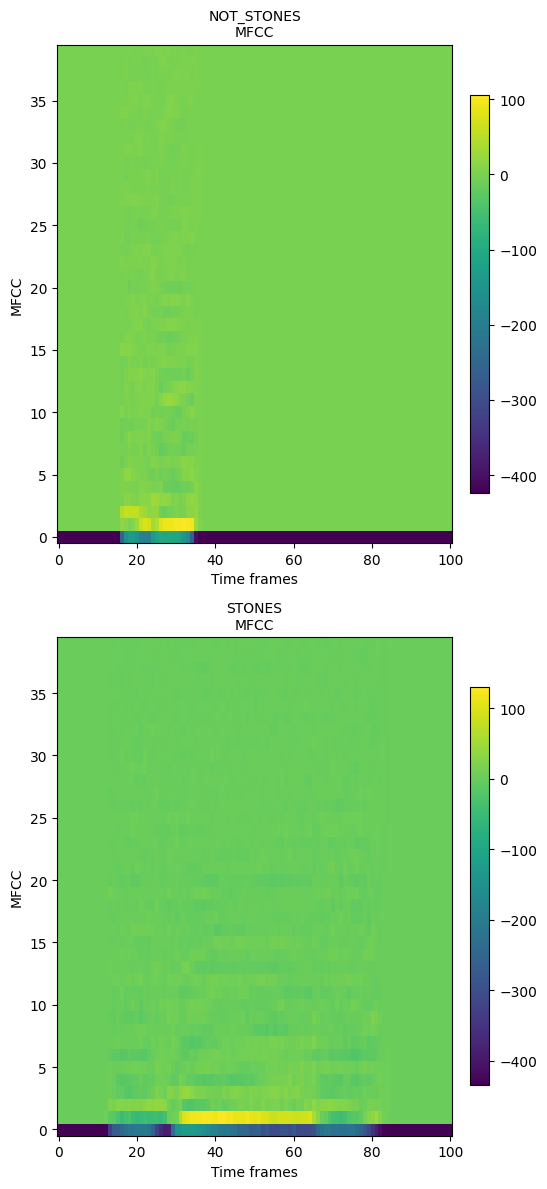

In [19]:
batch_features, batch_labels = next(iter(train_loader))

num_samples = min(2, len(batch_features))
fig = plt.figure(figsize=(15, 12))

for idx in range(num_samples):
    features = batch_features[idx].cpu().numpy()  # (time, features)
    label = batch_labels[idx].cpu().numpy()
    
    # Транспонируем для отображения (features, time)
    features_t = features.T

    class_name = "STONES" if label == 1 else "NOT_STONES"
    color = 'red' if label == 1 else 'blue'

    ax = plt.subplot(num_samples, 3, idx*3 + 1)
    
    # 1. Визуализация MFCC
    mfcc_part = features_t[:40, :]
    im = ax.imshow(mfcc_part, aspect='auto', origin='lower', 
                   cmap='viridis', interpolation='nearest')
    ax.set_title(f'{class_name}\nMFCC', fontsize=10)
    ax.set_ylabel('MFCC')
    ax.set_xlabel('Time frames')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Model

In [31]:
class StonesCNN(nn.Module):
    def __init__(self, input_shape, num_classes=2):
        super(StonesCNN, self).__init__()
        
        time_frames, n_features = input_shape
        
        self.conv_layers = nn.Sequential(
            # Блок 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(DROPOUT / 2),
            
            # Блок 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(DROPOUT),
            
            # Блок 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Dropout2d(DROPOUT),
        )
        
        test_input = torch.randn(1, 1, time_frames, n_features)
        test_output = self.conv_layers(test_input)
        flat_size = test_output.view(1, -1).size(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(flat_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(DROPOUT / 2),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [46]:
sample_features, _ = train_dataset[0]
input_shape = sample_features.shape

model = StonesCNN(input_shape, num_classes=2)

In [47]:
input_shape

torch.Size([101, 120])

# Train

In [33]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_f1 = correct / total
    
    return epoch_loss, epoch_f1

In [34]:
def validate(model, dataloader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    
    f1 = f1_score(all_labels, all_preds)
    
    return epoch_loss, f1, all_preds, all_labels

In [35]:
train_losses = []
val_losses = []
train_f1s = []
val_f1s = []

def train_model(model, train_loader, val_loader, epochs=EPOCHS):
    device = DEVICE
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer = optim.AdamW(model.parameters(), 
                            lr=LEARNING_RATE, 
                            weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )
    
    best_val_f1 = 0
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        # Обучение
        train_loss, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        train_losses.append(train_loss)
        train_f1s.append(train_f1)
        
        # Валидация
        val_loss, val_f1, _, _ = validate(
            model, val_loader, criterion, device
        )
        val_losses.append(val_loss)
        val_f1s.append(val_f1)
        
        # Scheduler step
        scheduler.step(val_loss)
        
        print(f"Train Loss: {train_loss:.4f}, Train F1: {train_f1:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val F1: {val_f1:.2f}%")
        
        # Сохраняем лучшую модель
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"Saved best model with val_f1: {val_f1:.2f}%")
    
    return model

In [36]:
def plot_training_history(train_losses, val_losses, train_f1s, val_f1s):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(train_losses, label='train loss')
    ax1.plot(val_losses, label='val loss')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('loss')
    ax1.legend()
    ax1.set_title('TLoss')
    ax1.grid(True)
    
    ax2.plot(train_f1s, label='Train F1')
    ax2.plot(val_f1s, label='Val F1')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1')
    ax2.legend()
    ax2.set_title('Training and Validation F1')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

In [43]:
model = train_model(model, train_loader, val_loader)


Epoch 1/100


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.23it/s]


Train Loss: 0.6069, Train F1: 0.70%
Val Loss: 0.5477, Val F1: 0.69%
Saved best model with val_f1: 0.69%

Epoch 2/100


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.47it/s]


Train Loss: 0.6113, Train F1: 0.66%
Val Loss: 0.5533, Val F1: 0.62%

Epoch 3/100


...

Train Loss: 0.4609, Train F1: 0.78%
Val Loss: 0.4502, Val F1: 0.64%

Epoch 99/100


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.09it/s]


Train Loss: 0.4076, Train F1: 0.79%
Val Loss: 0.4273, Val F1: 0.68%

Epoch 100/100


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.08it/s]

Train Loss: 0.4470, Train F1: 0.78%
Val Loss: 0.4073, Val F1: 0.70%


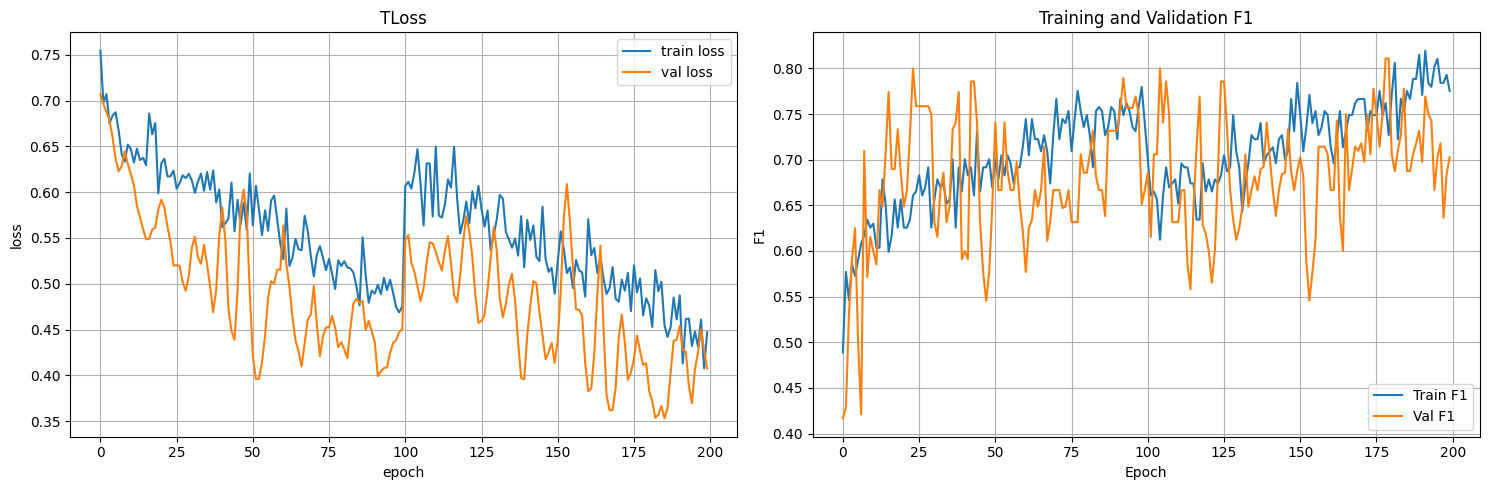

In [44]:
# Визуализация обучения
plot_training_history(train_losses, val_losses, train_f1s, val_f1s)

In [39]:
# Загрузка лучшей модели
model.load_state_dict(torch.load(MODEL_PATH))

<All keys matched successfully>

In [40]:
# Оценка на валидации

criterion = nn.CrossEntropyLoss()
_, _, all_preds, all_labels = validate(model, val_loader, criterion, DEVICE)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.45it/s]


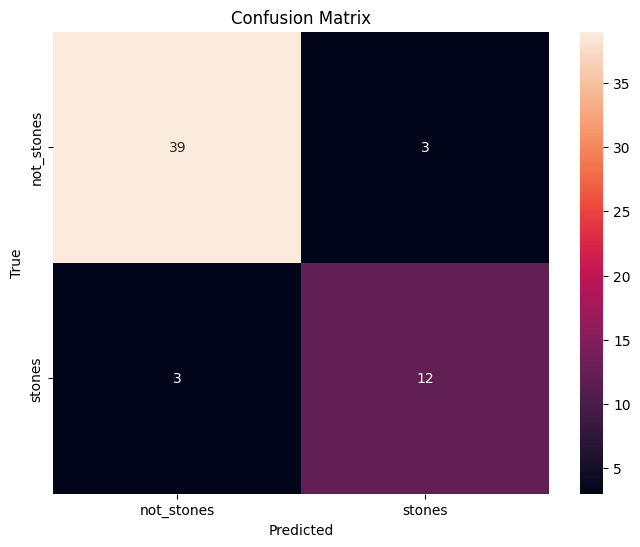

In [41]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            xticklabels=['not_stones', 'stones'],
            yticklabels=['not_stones', 'stones']
)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

In [42]:
# Расчет метрик
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1:.4f}')

Accuracy:  0.8947
Precision: 0.8000
Recall:    0.8000
F1-score:  0.8000


# Inference example

In [424]:
def merge_detections(detections, min_gap=0.5):
    """Объединяет близкие детекции в одну"""
    if not detections:
        return []
    
    detections.sort(key=lambda x: x['start_time'])
    merged = [detections[0]]
    
    for current in detections[1:]:
        last = merged[-1]
        if current['start_time'] - last['end_time'] < min_gap:
            # Объединяем
            last['end_time'] = max(last['end_time'], current['end_time'])
            last['confidence'] = max(last['confidence'], current['confidence'])
        else:
            merged.append(current)
    
    return merged

In [425]:
def detect_stones_in_file(model, audio_file, threshold=THRESHOLD):
    """
    Детекция слова STONES в длинном аудио файле
    
    Returns:
        detections: список словарей с временными метками
    """
    model.eval()
    device = DEVICE
    
    # Загружаем аудио
    y, sr = librosa.load(audio_file, sr=SAMPLE_RATE)
    duration = len(y) / sr
    
    # Длина окна и шаг с оверлапом
    window_length = int(SAMPLE_RATE * DURATION)
    hop_length = int(window_length * 0.5)  # 50% оверлап
    
    detections = []
    for start in range(0, len(y) - window_length, hop_length):
        # Вырезаем окно
        window = y[start:start + window_length]
        
        # Извлекаем признаки
        mfcc = librosa.feature.mfcc(
            y=y, 
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            n_mels=N_MELS
        )
        
        # Дельты
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        features = np.vstack([mfcc, mfcc_delta, mfcc_delta2]).T
        
        input_tensor = torch.FloatTensor(features).unsqueeze(0).to(device)
        
        # Предсказание
        with torch.no_grad():
            outputs = model(input_tensor)
            probabilities = F.softmax(outputs, dim=1)
            confidence = probabilities[0, 1].item()
        
        if confidence > threshold:
            start_time = start / sr
            detections.append({
                'start_time': start_time,
                'end_time': start_time + DURATION,
                'confidence': confidence,
                'word': 'STONES'
            })
    
    # Пост-обработка: объединяем близкие детекции
    detections = merge_detections(detections)
    
    return detections

In [426]:
def save_detection_segments(audio_file, detections, output_dir='found_detections'):
    """Сохраняет обнаруженные сегменты в отдельные файлы"""
    os.makedirs(output_dir, exist_ok=True)
    
    y, sr = librosa.load(audio_file, sr=SAMPLE_RATE)
    
    saved_files = []
    for i, det in enumerate(detections):
        start_sample = int(det['start_time'] * sr)
        end_sample = int(det['end_time'] * sr)
        segment = y[start_sample:end_sample]
        
        output_file = f"{output_dir}/stones_{i+1}_{det['start_time']:.2f}s.wav"
        sf.write(output_file, segment, sr)
        saved_files.append(output_file)
        print(f"Saved segment to {output_file}")
    
    return saved_files

In [429]:
def test_on_assignment_file(model, audio_file):
    """Тестирование модели на файле из задания"""
    
    # Детекция
    detections = detect_stones_in_file(model, audio_file, threshold=THRESHOLD)
    
    # Сохранение результатов
    print(f"\nFound {len(detections)} STONES occurrences:")
    for i, det in enumerate(detections, 1):
        print(f"{i}. Time: {det['start_time']:.2f}s - {det['end_time']:.2f}s, "
              f"Confidence: {det['confidence']:.3f}")
    
    # Сохраняем сегменты
    if detections:
        saved_files = save_detection_segments(audio_file, detections)
        print(f"\nSaved {len(saved_files)} segments to 'detections/' directory")
    
    # Сохраняем результаты в JSON
    results = {
        'file': audio_file,
        'detections': detections,
        'threshold': THRESHOLD,
        'model': str(MODEL_PATH)
    }
    
    with open('data/detection_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    return detections

In [ ]:
detections = test_on_assignment_file(model, '../data/thanos_message.wav')